# AdaptCLIP defect-type sample score summary

`results/adaptclip/*_sample_score/sample_scores_*.csv` files are loaded and grouped by `dataset`, `class`, and parsed `defect_type`.

In [1]:
from pathlib import Path

import pandas as pd

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 50)

RESULT_ROOT = Path("results/adaptclip")
OUTPUT_CSV = RESULT_ROOT / "defect_type_mean_scores.csv"

score_files = sorted(RESULT_ROOT.glob("*_sample_score/sample_scores_*.csv"))
print(f"Found {len(score_files)} score files")
for path in score_files:
    print(path)

Found 9 score files
results\adaptclip\cable_sample_score\sample_scores_mvtec_10seed_0shot.csv
results\adaptclip\cashew_sample_score\sample_scores_visa_10seed_0shot.csv
results\adaptclip\macaroni1_sample_score\sample_scores_visa_10seed_0shot.csv
results\adaptclip\macaroni2_sample_score\sample_scores_visa_10seed_0shot.csv
results\adaptclip\pcb2_sample_score\sample_scores_visa_10seed_0shot.csv
results\adaptclip\pcb3_sample_score\sample_scores_visa_10seed_0shot.csv
results\adaptclip\pill_sample_score\sample_scores_mvtec_10seed_0shot.csv
results\adaptclip\screw_sample_score\sample_scores_mvtec_10seed_0shot.csv
results\adaptclip\transistor_sample_score\sample_scores_mvtec_10seed_0shot.csv


In [2]:
def parse_defect_type(row):
    parts = str(row["query_path"]).replace("\\", "/").split("/")
    dataset = str(row["dataset"]).lower()

    if dataset == "mvtec" and "test" in parts:
        idx = parts.index("test")
        if idx + 1 < len(parts):
            return parts[idx + 1]

    if dataset == "visa" and "Images" in parts:
        idx = parts.index("Images")
        if idx + 1 < len(parts):
            return parts[idx + 1]

    if int(row["label"]) == 0:
        return "good"
    return "unknown_anomaly"


if not score_files:
    raise FileNotFoundError(f"No sample score CSVs found under {RESULT_ROOT}")

frames = []
for path in score_files:
    df = pd.read_csv(path)
    df["source_file"] = str(path)
    frames.append(df)

scores = pd.concat(frames, ignore_index=True)
scores["image_score"] = pd.to_numeric(scores["image_score"], errors="coerce")
scores["label"] = pd.to_numeric(scores["label"], errors="coerce").astype("Int64")
scores["defect_type"] = scores.apply(parse_defect_type, axis=1)

scores.head()

,dataset,sample_id,class,label,image_score,query_path,source_file,defect_type
0,mvtec,0,cable,1,0.905843,dataset\MVTec\cable/test/bent_wire/000.png,results\adaptclip\cable_sample_score\sample_sc...,bent_wire
1,mvtec,1,cable,1,0.817043,dataset\MVTec\cable/test/bent_wire/001.png,results\adaptclip\cable_sample_score\sample_sc...,bent_wire
2,mvtec,2,cable,1,0.845925,dataset\MVTec\cable/test/bent_wire/002.png,results\adaptclip\cable_sample_score\sample_sc...,bent_wire
3,mvtec,3,cable,1,0.836002,dataset\MVTec\cable/test/bent_wire/003.png,results\adaptclip\cable_sample_score\sample_sc...,bent_wire
4,mvtec,4,cable,1,0.828381,dataset\MVTec\cable/test/bent_wire/004.png,results\adaptclip\cable_sample_score\sample_sc...,bent_wire


In [3]:
summary = (
    scores
    .groupby(["dataset", "class", "defect_type", "label"], dropna=False)
    .agg(
        n=("image_score", "size"),
        mean_image_score=("image_score", "mean"),
        std_image_score=("image_score", "std"),
        min_image_score=("image_score", "min"),
        max_image_score=("image_score", "max"),
    )
    .reset_index()
    .sort_values(["dataset", "class", "label", "mean_image_score"], ascending=[True, True, True, False])
)

summary

,dataset,class,defect_type,label,n,mean_image_score,std_image_score,min_image_score,max_image_score
5,mvtec,cable,good,0,58,0.825474,0.015927,0.795723,0.867881
4,mvtec,cable,cut_outer_insulation,1,10,0.892508,0.034973,0.854288,0.941378
8,mvtec,cable,poke_insulation,1,10,0.874194,0.029686,0.823909,0.922815
2,mvtec,cable,combined,1,11,0.868162,0.027782,0.839043,0.908097
7,mvtec,cable,missing_wire,1,10,0.862161,0.026062,0.821091,0.925304
0,mvtec,cable,bent_wire,1,13,0.854866,0.029544,0.817043,0.905843
3,mvtec,cable,cut_inner_insulation,1,14,0.847740,0.024093,0.820063,0.890168
1,mvtec,cable,cable_swap,1,12,0.841732,0.019556,0.813792,0.879405
6,mvtec,cable,missing_cable,1,12,0.833719,0.021594,0.789527,0.865190
14,mvtec,pill,good,0,26,0.470406,0.133233,0.302469,0.791385


In [4]:
OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)
summary.to_csv(OUTPUT_CSV, index=False)
print(f"Saved: {OUTPUT_CSV}")

Saved: results\adaptclip\defect_type_mean_scores.csv


In [5]:
# Optional: view one class only.
CLASS_NAME = "transistor"
summary.query("`class` == @CLASS_NAME")

,dataset,class,defect_type,label,n,mean_image_score,std_image_score,min_image_score,max_image_score
26,mvtec,transistor,good,0,60,0.739425,0.055016,0.633760,0.877825
25,mvtec,transistor,damaged_case,1,10,0.903799,0.032121,0.847596,0.947294
23,mvtec,transistor,bent_lead,1,10,0.840433,0.043248,0.769171,0.909635
24,mvtec,transistor,cut_lead,1,10,0.824478,0.060989,0.739087,0.911719
27,mvtec,transistor,misplaced,1,10,0.808609,0.072924,0.686977,0.910482


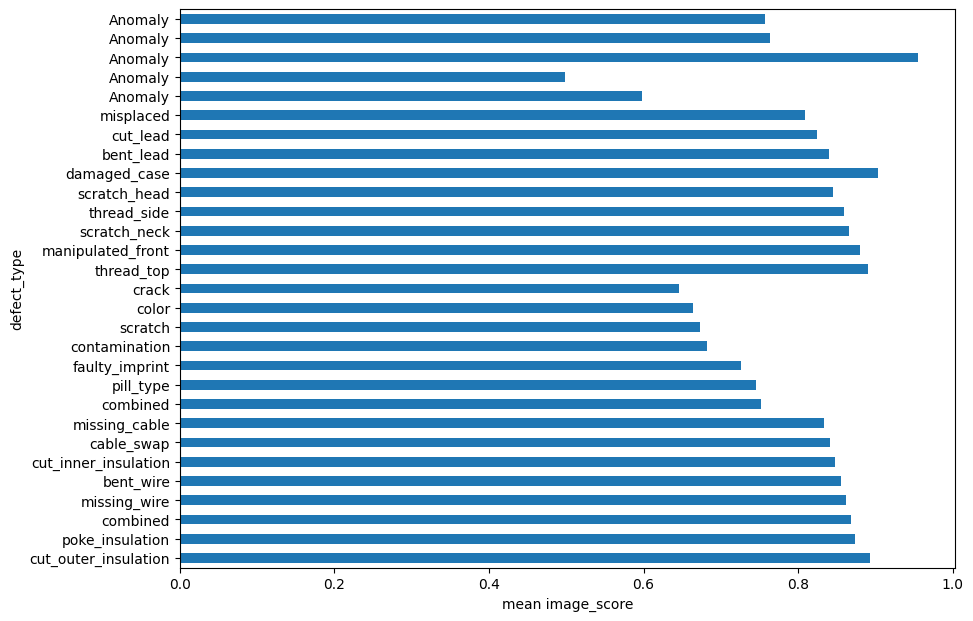

In [6]:
# Optional: quick bar plot for anomaly defect types only.
plot_df = summary.query("label == 1").copy()
if not plot_df.empty:
    ax = plot_df.plot.barh(
        x="defect_type",
        y="mean_image_score",
        figsize=(10, max(4, len(plot_df) * 0.25)),
        legend=False,
    )
    ax.set_xlabel("mean image_score")
    ax.set_ylabel("defect_type")